# **Modelos secuenciales: LSTM inter-época e híbrido CNN1D $\to$ BiLSTM**

Este cuaderno entrena y compara los **dos modelos secuenciales** del proyecto con **una sola función** (`src.lstm.train`) y el **mismo split por sujeto**, para que sus métricas sean directamente comparables:

1. **LSTM tabular** (`hybrid=False`): una BiLSTM many-to-many sobre la secuencia de **features handcrafted** por época (`epoch_features.csv`). El encoder intra-época es `IdentityEncoder` (pasa las features tal cual). Modela la **dinámica inter-época**.
2. **Híbrido CNN1D $\to$ BiLSTM** (`hybrid=True`): una **CNN 1D** (`CNNEpochEncoder`) resume la **señal cruda** de cada época (`sequences/*.npz`, `[150, 4]`) en un vector, y la BiLSTM lee esa secuencia. Se entrena **end-to-end** (una sola loss ajusta CNN y LSTM juntas). Combina morfología **intra-época** y dinámica **inter-época**.

## Arquitectura común
$$\text{época}[\dots] \;\xrightarrow{\text{encoder}}\; [T, F_{enc}] \;\xrightarrow{\text{BiLSTM (2 capas)}}\; \text{Dropout} \to \text{Linear} \to \text{logits}[T, 5]$$

- **encoder**: `IdentityEncoder` (tabular, $F_{enc}=122$) o `CNNEpochEncoder` (híbrido, $F_{enc}=128$). Es el único punto que cambia entre modos.
- **BiLSTM**: `hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True`. Lee la noche hacia adelante y hacia atrás (sleep staging offline → sin restricción de causalidad).
- **Padding + packing**: las noches tienen largo variable; `collate_nights` paddea al máximo del batch (features con 0.0, labels con `UNKNOWN=5`) y `pack_padded_sequence` hace que la LSTM ignore el relleno. La loss usa `ignore_index=UNKNOWN` (Unknown + padding fuera de la loss y de las métricas).
- **Loss**: `CrossEntropyLoss` con **pesos de clase** inversos a la frecuencia (desbalance N2 ≫ N1) + **gradient clipping**.

## Split y comparabilidad
El split es **por sujeto** (`partition_subjects`, sujetos disjuntos train/val/test), con la **misma seed y fracciones** para los dos modelos $\implies$ **exactamente los mismos sujetos** en cada partición. Así la diferencia de Kappa entre LSTM e híbrido refleja el modelo, no la partición.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, glob
sys.path.append("..")

# import temprano de torch._dynamo: evita un fallo de sympy con kernel de estado sucio.
import torch
import torch._dynamo  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lstm import ConfigLSTM, train, evaluate, plot_history, STAGE_NAMES
from src.sequence_data import build_night_sequences

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos (se generan solo si faltan)

- **`epoch_features.csv`** (modo tabular): lo produce `baseline.ipynb` (feature extraction). Si no existe, se genera acá.
- **`sequences/*.npz`** (modo híbrido): señal cruda por noche + `night_id`. Proceso **pesado (~30 min)**; se saltea si ya está poblado.

Ambos derivan de los mismos pacientes, así que el split por sujeto coincide entre modos.

In [2]:
FEATURES = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES):
    print(f"{FEATURES} ya existe; se omite la extracción.")
else:
    from src.feature_extraction import feature_extraction
    feature_extraction()

SEQ_DIR = "../data_extraction/sequences"
if glob.glob(os.path.join(SEQ_DIR, "*.npz")):
    print(f"{SEQ_DIR} ya tiene datos; se omite el procesamiento.")
else:
    build_night_sequences(output_dir=SEQ_DIR)

../data_extraction/epoch_features.csv ya existe; se omite la extracción.
../data_extraction/sequences ya tiene datos; se omite el procesamiento.


## 2. Configuración y split compartido

Dos `ConfigLSTM` que difieren solo en el modo (`hybrid`) y el checkpoint. La **misma seed** garantiza el **mismo split por sujeto** para los dos. `TRAIN_NEW` es la constante universal entrenar-de-cero / usar-guardado.

In [3]:
TRAIN_NEW = True  # True: entrena de cero y sobreescribe el checkpoint; False: usa el .pt guardado

# Misma seed/fracciones -> MISMO split por sujeto para ambos modelos (comparables).
cfg_lstm = ConfigLSTM(hybrid=False, ckpt_path="../models/best_lstm.pt")
cfg_hyb  = ConfigLSTM(hybrid=True,  ckpt_path="../models/best_cnn_lstm.pt",
                      hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True,
                      batch_size=8, lr=1e-3, epochs=40, use_class_weights=True)

## 3. LSTM tabular (inter-época)

BiLSTM sobre las 122 features handcrafted ([epoch_features.csv](data_extraction/epoch_features.csv)).

In [4]:
if TRAIN_NEW or not os.path.exists(cfg_lstm.ckpt_path):
    model_lstm, hist_lstm, test_lstm = train(cfg_lstm)
else:
    model_lstm, test_lstm = evaluate(cfg_lstm)
    hist_lstm = None

entrenando (LSTM tabular): 100%|██████████| 60/60 [06:36<00:00,  6.61s/epoch, train_loss=0.2611, val_loss=1.9443, val_kappa=0.4146, best=0.4499] 



TEST (LSTM tabular) — mejor ckpt (val kappa 0.4499, epoch 27):
  kappa 0.4435 | macroF1 0.5592 | acc 0.5666
  4-clases: kappa 0.4769 | macroF1 0.6448 | acc 0.6405


## 4. Híbrido CNN1D → BiLSTM (end-to-end)

La misma `train`, con `hybrid=True`: el `CNNEpochEncoder` (GroupNorm, robusto al padding) resume cada época de señal cruda `[150, 4]` en 128 features y la BiLSTM lee la secuencia. Más lento (la CNN corre sobre todas las épocas de cada noche); conviene GPU.

In [5]:
if TRAIN_NEW or not os.path.exists(cfg_hyb.ckpt_path):
    model_hyb, hist_hyb, test_hyb = train(cfg_hyb)
else:
    model_hyb, test_hyb = evaluate(cfg_hyb)
    hist_hyb = None

entrenando (híbrido CNN1D->BiLSTM): 100%|██████████| 40/40 [10:08<00:00, 15.21s/epoch, train_loss=0.9964, val_loss=1.0816, val_kappa=0.3832, best=0.4033] 



TEST (híbrido CNN1D->BiLSTM) — mejor ckpt (val kappa 0.4033, epoch 39):
  kappa 0.3875 | macroF1 0.5023 | acc 0.5159
  4-clases: kappa 0.4037 | macroF1 0.5766 | acc 0.5756


## 5. Curvas de entrenamiento (train vs validación)

Para cada modelo: (izq) loss de **train vs validación** por epoch — si divergen, sobreajuste; (der) métricas de **validación** (kappa/macro-F1/accuracy) que muestran en qué epoch quedó el mejor checkpoint. Solo disponibles si se entrenó en esta corrida (`TRAIN_NEW=True` o checkpoint ausente).

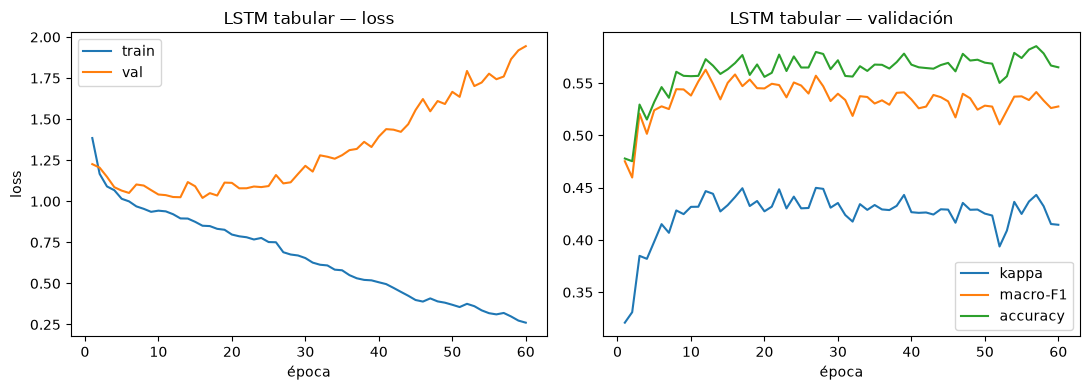

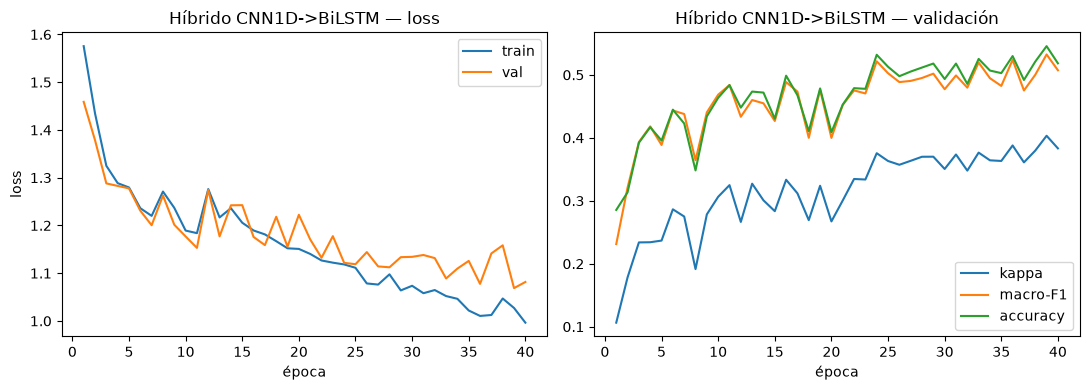

In [6]:
for name, hist in [('LSTM tabular', hist_lstm), ('Híbrido CNN1D->BiLSTM', hist_hyb)]:
    if hist is None:
        print(f"{name}: sin history (TRAIN_NEW=False); se omiten las curvas.")
    else:
        plot_history(hist, title=name)
        plt.tight_layout(); plt.show()

## 6. Comparación en test (mismo split)

Métricas de test de los dos modelos, calculadas sobre el **mismo test set por sujeto**: Cohen's Kappa (principal), macro-F1 y accuracy, en 5 clases y en la vista colapsada a 4 (Wake / Light=N1+N2 / Deep=N3 / REM). Más la matriz de confusión de cada uno.

In [7]:
rows = []
for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    rows.append({'modelo': name, 'kappa': tm['kappa'], 'macro_f1': tm['macro_f1'],
                 'accuracy': tm['accuracy'], 'kappa_4': tm['kappa_4'],
                 'macro_f1_4': tm['macro_f1_4'], 'accuracy_4': tm['accuracy_4']})
summary = pd.DataFrame(rows).set_index('modelo').round(4)
print("Test (mismo split por sujeto, vs Expert):")
print(summary.to_string())

for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    print(f"\nMatriz de confusión — {name} (5 clases):")
    print(pd.DataFrame(tm['confusion'], index=STAGE_NAMES, columns=STAGE_NAMES))

Test (mismo split por sujeto, vs Expert):
               kappa  macro_f1  accuracy  kappa_4  macro_f1_4  accuracy_4
modelo                                                                   
LSTM tabular  0.4435    0.5592    0.5666   0.4769      0.6448      0.6405
Híbrido       0.3875    0.5023    0.5159   0.4037      0.5766      0.5756

Matriz de confusión — LSTM tabular (5 clases):
      Wake    N1    N2    N3   REM
Wake  1988   873   173    93   365
N1     285  1302   307   116   930
N2     246  2018  5506  1587  2902
N3      51   362   612  4480   525
REM     81  1038   897   176  4552

Matriz de confusión — Híbrido (5 clases):
      Wake    N1    N2    N3   REM
Wake  2168   563   111   232   292
N1     587  1051   196   171   774
N2    1121  1566  4270  1348  3177
N3     574   234   679  3895   273
REM    223  1107   686   370  3838


## 7. Overview de una noche con las predicciones

Como el `night_overview` del EDA, pero agregando debajo de las señales los **hipnogramas** de Expert, Dreem y las predicciones de **ambos modelos** (LSTM tabular e híbrido), alineados por índice de época. Permite ver *dónde* acierta o falla cada modelo a lo largo de la noche (típicamente en las transiciones y en N1).

> El hipnograma del híbrido necesita que los `.npz` de `sequences/` tengan el índice de época (`epoch`), agregado a `build_night_sequences`. Si tus `sequences/` son previos a ese cambio, re-generalos (borrá `data_extraction/sequences/` y re-corré la celda de datos); si no, esa fila se omite.

overview de P20 N1
fila híbrido omitida: "los .npz no tienen 'epoch': re-generá sequences con build_night_sequences"


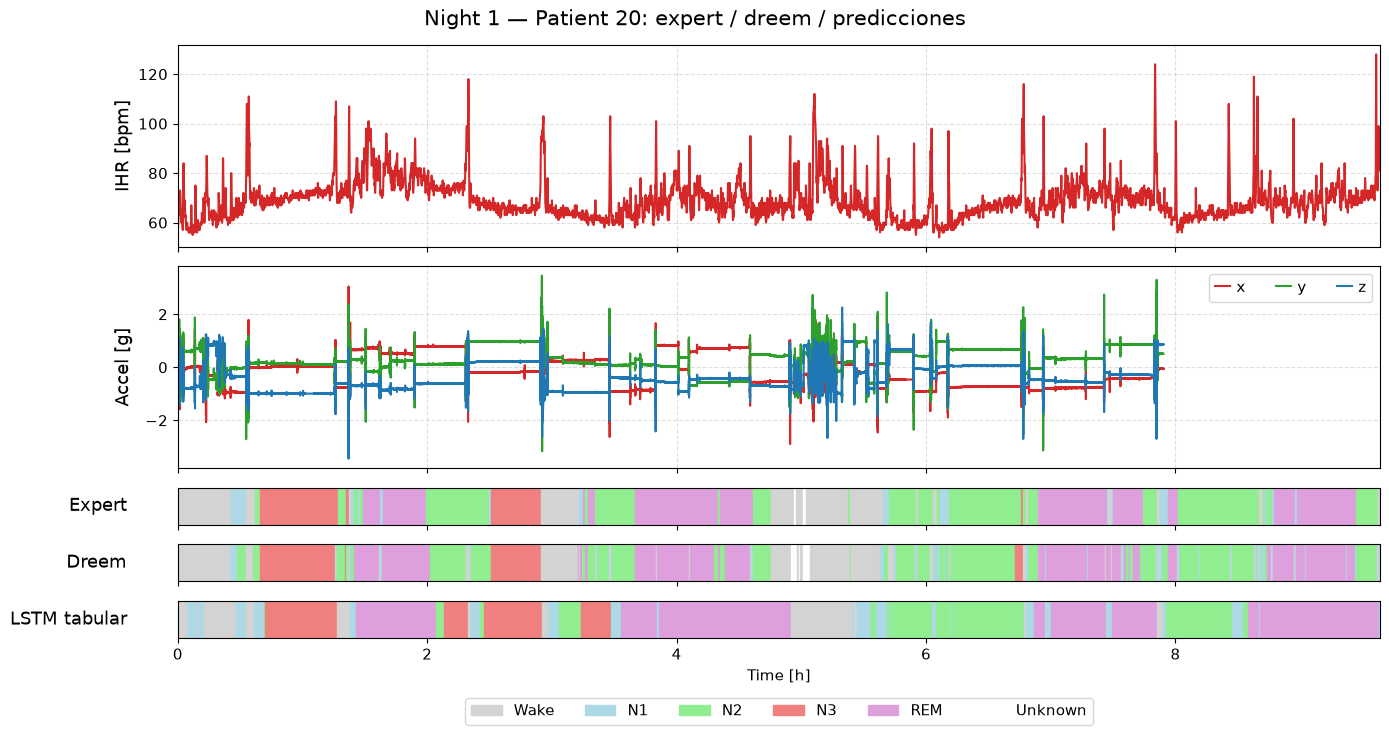

In [11]:
from src.plots import night_prediction_overview
from src.lstm import predict_night

# una noche del test set (sujetos de test del split compartido, guardados en el checkpoint)
ckpt = torch.load(cfg_lstm.ckpt_path, map_location='cpu', weights_only=False)
subject = sorted(ckpt['subj']['test'])[0]
night = int(pd.read_csv(cfg_lstm.features_path).query('subject == @subject')['night'].min())
print(f"overview de P{subject:02d} N{night}")

preds = {'LSTM tabular': predict_night(model_lstm, cfg_lstm, subject, night)}
try:
    preds['Híbrido'] = predict_night(model_hyb, cfg_hyb, subject, night)
except KeyError as e:
    print(f"fila híbrido omitida: {e}")

night_prediction_overview(subject, night, preds)